# Analyse avant ACM - données KaraFun

Avant de regrouper les modalités, on regarde les statistiques descriptives et les liens entre les variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

## 1. Chargement des données

In [2]:
df = pd.read_csv("td_clustering_karafun.csv")
print(df.shape)
df.head()

(341092, 16)


,id_anonyme,anciennete_client_tr,anciennete_abonnement_tr,statut_abonnement,type_client,type_very_first_abo,type_first_abo_last_streak,ratio_fidelite_tr,methode_paiement,nb_abo_periode,valeur_12M_tr,avg_sessions_actifs_tr,avg_songs_sessions_tr,utilise_remote,zone_geo,contactable
0,fbb58c58395ab62899c58d6a52f8159ca12ddd7f46bfe2...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Apple,1,00_moins_10,02_1a2,01_1a2,non,US,oui
1,8c981dbb88db4abcfd1c07b30ec42c370195fabaf74b8a...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Android,1,00_moins_10,03_2a3,02_2a3,non,Europe,oui
2,a4b6c3d31fb413aa830dbb423bd3d8446438dae71d9973...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,03_2a3,09_15a20,non,Europe,non
3,ef9a45455295911d59cd8a9c76d32d582709e40a5a238f...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,02_1a2,09_15a20,non,CA,oui
4,91d37bd372c738eddb00a6b2878877161fb26a2a519bf8...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,00_pas_de_session,00_pas_de_session,non,FR,oui


## 2. Types et valeurs manquantes

In [3]:
print(df.dtypes)

id_anonyme                      str
anciennete_client_tr            str
anciennete_abonnement_tr        str
statut_abonnement               str
type_client                     str
type_very_first_abo             str
type_first_abo_last_streak      str
ratio_fidelite_tr               str
methode_paiement                str
nb_abo_periode                int64
valeur_12M_tr                   str
avg_sessions_actifs_tr          str
avg_songs_sessions_tr           str
utilise_remote                  str
zone_geo                        str
contactable                     str
dtype: object


In [4]:
print(df.isna().sum())

id_anonyme                    0
anciennete_client_tr          0
anciennete_abonnement_tr      0
statut_abonnement             0
type_client                   0
type_very_first_abo           0
type_first_abo_last_streak    0
ratio_fidelite_tr             0
methode_paiement              0
nb_abo_periode                0
valeur_12M_tr                 0
avg_sessions_actifs_tr        0
avg_songs_sessions_tr         0
utilise_remote                0
zone_geo                      0
contactable                   0
dtype: int64


In [5]:
# nombre de modalités par variable
print(df.nunique())

id_anonyme                    341092
anciennete_client_tr              20
anciennete_abonnement_tr          20
statut_abonnement                  2
type_client                        4
type_very_first_abo                3
type_first_abo_last_streak         3
ratio_fidelite_tr                  6
methode_paiement                   7
nb_abo_periode                    12
valeur_12M_tr                     12
avg_sessions_actifs_tr            14
avg_songs_sessions_tr             13
utilise_remote                     2
zone_geo                          11
contactable                        2
dtype: int64


In [6]:
print(df["id_anonyme"].duplicated().sum())

0


Pas de valeurs manquantes et pas de doublons. `nb_abo_periode` est la seule variable numérique, il faudra la mettre en classes pour l'ACM.

## 3. Variable nb_abo_periode

In [7]:
print(df["nb_abo_periode"].describe())

count    341092.000000
mean          5.454860
std           4.356785
min           1.000000
25%           1.000000
50%           4.000000
75%          10.000000
max          12.000000
Name: nb_abo_periode, dtype: float64


In [8]:
pct = df["nb_abo_periode"].value_counts(normalize=True).sort_index() * 100
print(pct.round(1))

nb_abo_periode
1     28.5
2     12.0
3      7.5
4      5.5
5      4.5
6      4.3
7      4.6
8      3.1
9      2.8
10     2.7
11     3.6
12    21.0
Name: proportion, dtype: float64


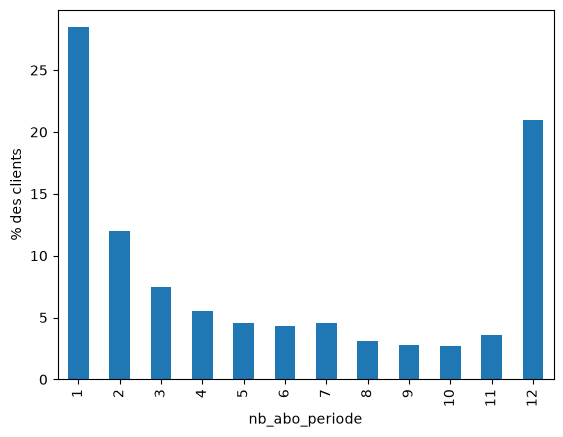

In [9]:
pct.plot(kind="bar")
plt.xlabel("nb_abo_periode")
plt.ylabel("% des clients")
plt.show()

Distribution en U : beaucoup de clients à 1 et à 12, peu au milieu.

## 4. Variables qualitatives

In [10]:
variables = [
    "anciennete_client_tr",
    "anciennete_abonnement_tr",
    "statut_abonnement",
    "type_client",
    "type_very_first_abo",
    "type_first_abo_last_streak",
    "ratio_fidelite_tr",
    "methode_paiement",
    "valeur_12M_tr",
    "avg_sessions_actifs_tr",
    "avg_songs_sessions_tr",
    "utilise_remote",
    "zone_geo",
    "contactable",
]

In [11]:
for col in variables:
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    print(pct.round(1))
    print()

anciennete_client_tr
00_moins_1_mois         3.7
01_1_mois               3.7
02_2_mois               3.1
03_3_mois               3.0
04_4_mois               2.9
05_5_mois               3.6
06_6_mois               9.6
07_7a9_mois            10.4
08_10a12_mois           8.9
09_13a15_mois           4.9
10_16a18_mois           6.4
11_19a21_mois           3.9
12_22a24_mois           3.3
13_25a30_mois           7.1
14_31a36_mois           5.1
15_37a48_mois           6.4
16_49a60_mois           3.6
17_61a84_mois           4.4
18_85a120_mois          4.1
19_121_mois_et_plus     2.1
Name: proportion, dtype: float64

anciennete_abonnement_tr
00_moins_1_mois         7.5
01_1_mois               7.2
02_2_mois               5.7
03_3_mois               5.0
04_4_mois               4.9
05_5_mois               5.5
06_6_mois              13.6
07_7a9_mois            14.4
08_10a12_mois          10.7
09_13a15_mois           4.3
10_16a18_mois           4.1
11_19a21_mois           2.7
12_22a24_mois           

type_client
churn          50.3
nouveau        16.0
reactivated    14.6
retained       19.1
Name: proportion, dtype: float64

type_very_first_abo
offert     2.5
payant    96.9
reduc      0.6
Name: proportion, dtype: float64

type_first_abo_last_streak
offert     0.2
payant    99.1
reduc      0.7
Name: proportion, dtype: float64

ratio_fidelite_tr
01_moins_30              27.4
02_30a50                 11.5
03_50a70                 11.9
04_70a90                  9.4
05_90_et_plus            36.1
99_vient_de_s_abonner     3.7
Name: proportion, dtype: float64

methode_paiement
Amazon      0.8
Android    15.5
Apple      32.8
Credit      0.2
Others      0.0
Paypal     11.2
Stripe     39.5
Name: proportion, dtype: float64

valeur_12M_tr
00_moins_10       28.6
01_10a15           9.1
02_15a20           6.8
03_20a25           3.2
04_25a30           4.4
05_30a40           6.9
06_40a50           6.5
07_50a60           3.9
08_60a70           5.5
09_70a90          15.9
10_90a110          2.4
11_110_

avg_songs_sessions_tr
00_pas_de_session    11.9
01_1a2                8.2
02_2a3                7.4
03_3a4                6.7
04_4a5                6.2
05_5a6                5.7
06_6a8                9.9
07_8a10               8.1
08_10a15             14.2
09_15a20              8.3
10_20a30              8.0
11_30a50              4.4
12_50_et_plus         1.0
Name: proportion, dtype: float64



utilise_remote
non    75.1
oui    24.9
Name: proportion, dtype: float64

zone_geo
Afrique                 0.8
Amerique_Nord_Autre     0.8
Amerique_Sud            0.8
Asie                    1.1
Autre/Inconnu           0.0
CA                      7.0
Europe                 20.9
FR                     17.5
Oceanie                 2.4
UK                      7.3
US                     41.3
Name: proportion, dtype: float64



contactable
non    40.2
oui    59.8
Name: proportion, dtype: float64



### Modalités rares

On regarde les modalités qui font moins de 5 % des clients, ce sont celles qu'il faudra regrouper.

In [12]:
for col in variables:
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    rares = pct[pct < 5]
    print(col, ":", len(pct), "modalités dont", len(rares), "sous 5 %")
    print(rares.round(2))
    print()

anciennete_client_tr : 20 modalités dont 13 sous 5 %
anciennete_client_tr
00_moins_1_mois        3.66
01_1_mois              3.72
02_2_mois              3.07
03_3_mois              2.96
04_4_mois              2.88
05_5_mois              3.61
09_13a15_mois          4.91
11_19a21_mois          3.89
12_22a24_mois          3.26
16_49a60_mois          3.57
17_61a84_mois          4.42
18_85a120_mois         4.09
19_121_mois_et_plus    2.09
Name: proportion, dtype: float64

anciennete_abonnement_tr : 20 modalités dont 12 sous 5 %
anciennete_abonnement_tr
04_4_mois              4.90
09_13a15_mois          4.31
10_16a18_mois          4.12
11_19a21_mois          2.73
12_22a24_mois          2.15
13_25a30_mois          3.97
14_31a36_mois          2.41
15_37a48_mois          2.98
16_49a60_mois          1.43
17_61a84_mois          0.88
18_85a120_mois         0.42
19_121_mois_et_plus    0.04
Name: proportion, dtype: float64

statut_abonnement : 2 modalités dont 0 sous 5 %
Series([], Name: proportion,

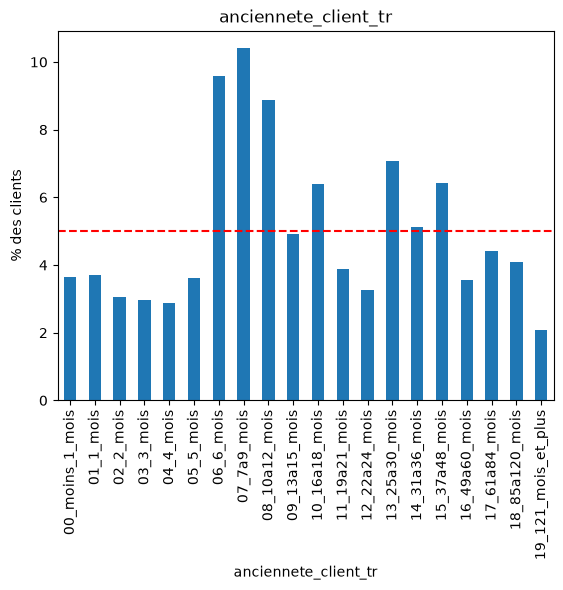

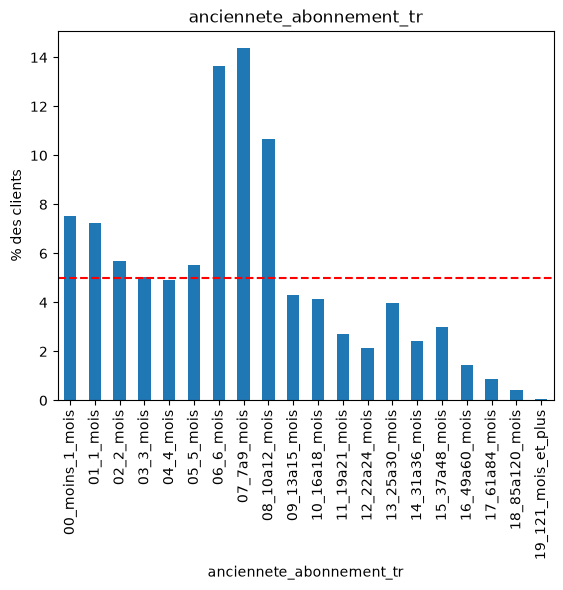

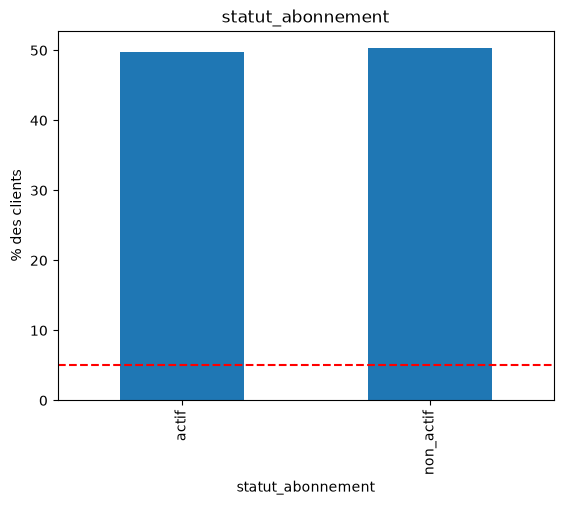

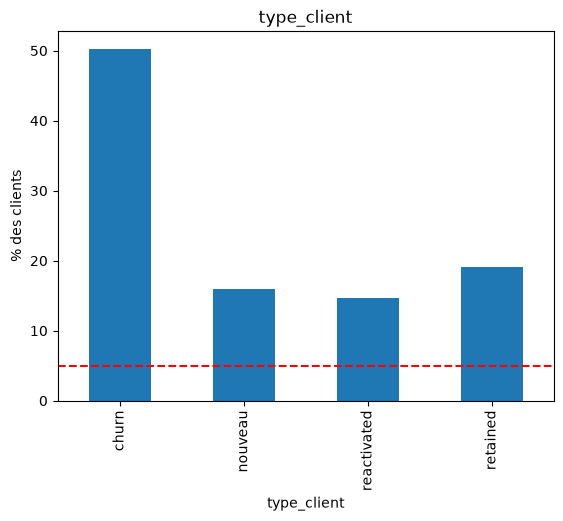

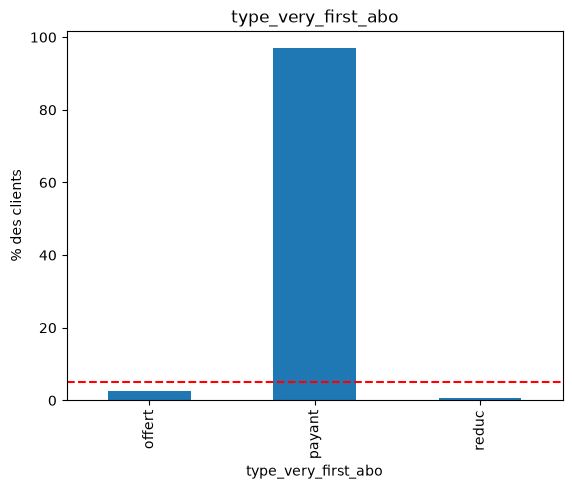

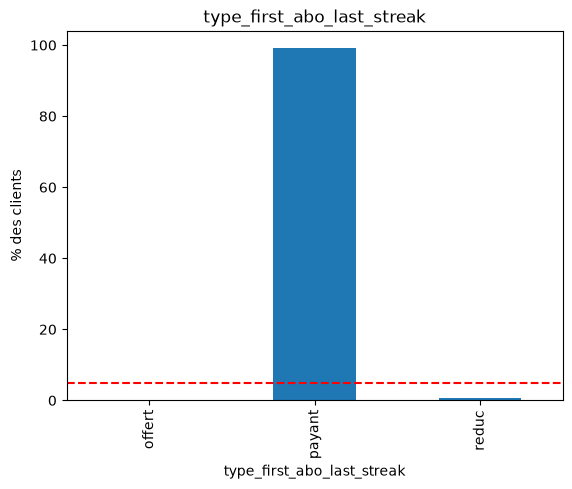

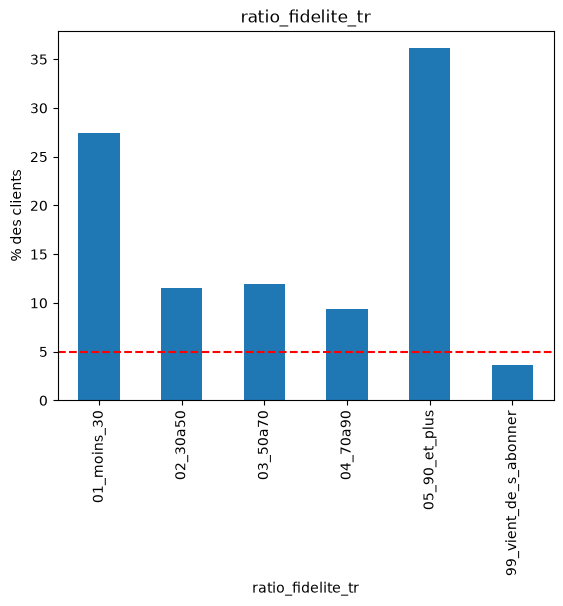

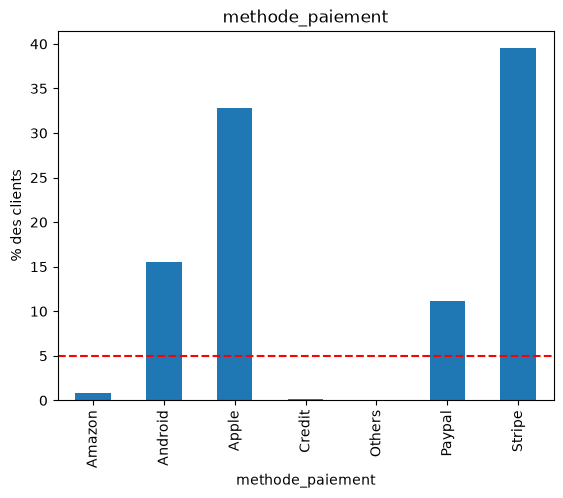

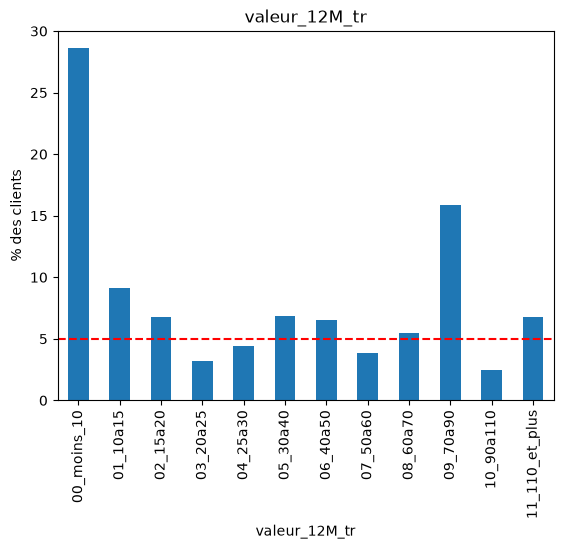

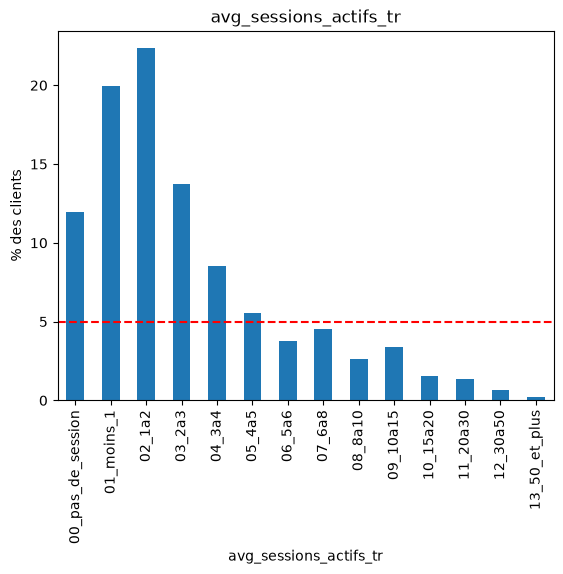

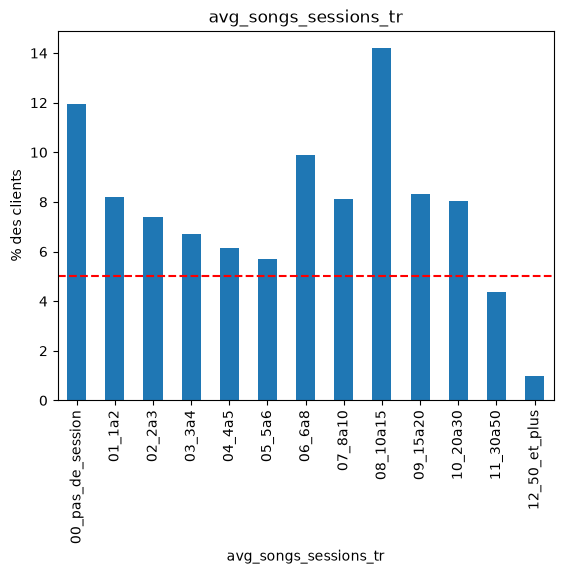

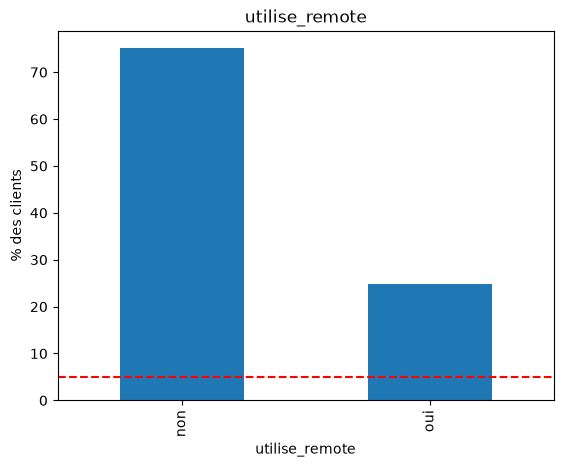

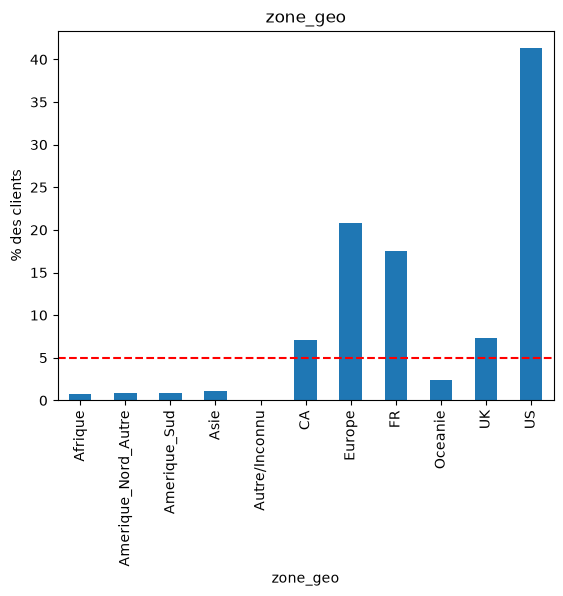

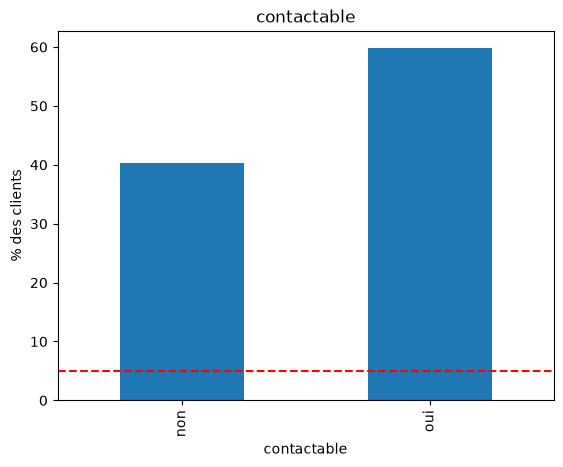

In [13]:
# la ligne rouge est le seuil de 5 %
for col in variables:
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    pct.plot(kind="bar")
    plt.axhline(5, color="red", linestyle="--")
    plt.title(col)
    plt.ylabel("% des clients")
    plt.show()

- `type_first_abo_last_streak` : 99 % de payant, la variable n'apporte presque rien
- `methode_paiement` : Others (1 client), Credit et Amazon sont très rares
- `zone_geo` : plusieurs petites zones autour de 1 %
- les anciennetés, sessions, chansons et valeur ont beaucoup de modalités, dont plusieurs sous 5 %

## 5. Liens entre les variables : V de Cramér

Avec 341 092 lignes le test du khi-deux est toujours significatif, donc on utilise le V de Cramér qui va de 0 (pas de lien) à 1 (lien parfait).

V = racine( khi2 / (n * (min(nb lignes, nb colonnes) - 1)) )

In [14]:
def cramer(var1, var2):
    tableau = pd.crosstab(df[var1], df[var2])
    chi2 = chi2_contingency(tableau)[0]
    n = len(df)
    k = min(tableau.shape) - 1
    return np.sqrt(chi2 / (n * k))

In [15]:
# exemple sur un couple
tableau = pd.crosstab(df["type_client"], df["utilise_remote"])
print(tableau)

resultat = chi2_contingency(tableau)
print("khi2 :", resultat[0])
print("p-value :", resultat[1])
print("V de Cramer :", cramer("type_client", "utilise_remote"))

utilise_remote     non    oui
type_client                  
churn           131888  39598
nouveau          38907  15714
reactivated      33522  16343
retained         51747  13373
khi2 : 3051.599615801947
p-value : 0.0
V de Cramer : 0.09458625030115726


La p-value vaut 0 alors que le V est faible (0,09). C'est pour ça qu'on regarde le V.

### Matrice des V de Cramér

In [16]:
variables2 = variables + ["nb_abo_periode"]

matrice = pd.DataFrame(index=variables2, columns=variables2, dtype=float)

for v1 in variables2:
    for v2 in variables2:
        matrice.loc[v1, v2] = cramer(v1, v2)

matrice.round(2)

,anciennete_client_tr,anciennete_abonnement_tr,statut_abonnement,type_client,type_very_first_abo,type_first_abo_last_streak,ratio_fidelite_tr,methode_paiement,valeur_12M_tr,avg_sessions_actifs_tr,avg_songs_sessions_tr,utilise_remote,zone_geo,contactable,nb_abo_periode
anciennete_client_tr,1.00,0.55,0.32,0.44,0.13,0.05,0.50,0.06,0.22,0.07,0.05,0.07,0.04,0.35,0.26
anciennete_abonnement_tr,0.55,1.00,0.48,0.54,0.07,0.08,0.40,0.08,0.25,0.10,0.07,0.14,0.05,0.18,0.29
statut_abonnement,0.32,0.48,1.00,1.00,0.07,0.01,0.69,0.08,0.62,0.27,0.17,0.04,0.12,0.03,0.64
type_client,0.44,0.54,1.00,1.00,0.16,0.02,0.51,0.08,0.53,0.18,0.12,0.09,0.08,0.17,0.59
type_very_first_abo,0.13,0.07,0.07,0.16,1.00,0.35,0.09,0.07,0.04,0.03,0.05,0.05,0.04,0.05,0.07
type_first_abo_last_streak,0.05,0.08,0.01,0.02,0.35,1.00,0.02,0.64,0.02,0.02,0.02,0.03,0.02,0.04,0.04
ratio_fidelite_tr,0.50,0.40,0.69,0.51,0.09,0.02,1.00,0.04,0.39,0.16,0.06,0.02,0.07,0.12,0.41
methode_paiement,0.06,0.08,0.08,0.08,0.07,0.64,0.04,1.00,0.16,0.03,0.07,0.07,0.11,0.20,0.05
valeur_12M_tr,0.22,0.25,0.62,0.53,0.04,0.02,0.39,0.16,1.00,0.13,0.05,0.06,0.12,0.12,0.63
avg_sessions_actifs_tr,0.07,0.10,0.27,0.18,0.03,0.02,0.16,0.03,0.13,1.00,0.30,0.21,0.04,0.09,0.13


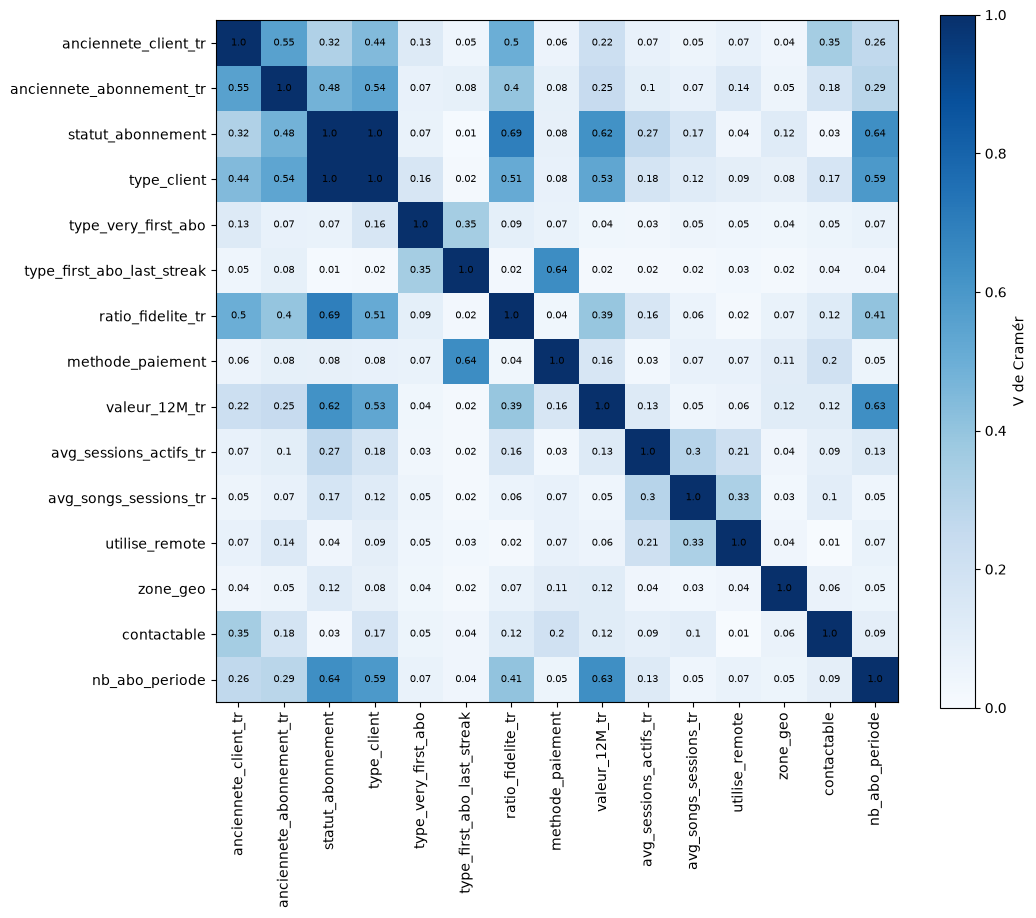

In [17]:
plt.figure(figsize=(11, 9))
plt.imshow(matrice, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="V de Cramér")
plt.xticks(range(len(variables2)), variables2, rotation=90)
plt.yticks(range(len(variables2)), variables2)

for i in range(len(variables2)):
    for j in range(len(variables2)):
        plt.text(j, i, round(matrice.iloc[i, j], 2), ha="center", va="center", fontsize=7)

plt.show()

In [18]:
# classement des couples (on prend j > i pour ne pas avoir chaque couple deux fois)
couples = []
for i in range(len(variables2)):
    for j in range(i + 1, len(variables2)):
        couples.append([variables2[i], variables2[j], round(matrice.iloc[i, j], 3)])

classement = pd.DataFrame(couples, columns=["variable_1", "variable_2", "V"])
classement = classement.sort_values("V", ascending=False)
classement.head(20)

,variable_1,variable_2,V
27,statut_abonnement,type_client,1.000
30,statut_abonnement,ratio_fidelite_tr,0.693
61,type_first_abo_last_streak,methode_paiement,0.644
38,statut_abonnement,nb_abo_periode,0.635
89,valeur_12M_tr,nb_abo_periode,0.633
32,statut_abonnement,valeur_12M_tr,0.621
49,type_client,nb_abo_periode,0.592
0,anciennete_client_tr,anciennete_abonnement_tr,0.555
15,anciennete_abonnement_tr,type_client,0.537
43,type_client,valeur_12M_tr,0.532


## 6. Tableaux croisés des couples les plus liés

### statut_abonnement et type_client (V = 1)

In [19]:
pd.crosstab(df["type_client"], df["statut_abonnement"])

statut_abonnement,actif,non_actif
type_client,,
churn,0,171486
nouveau,54621,0
reactivated,49865,0
retained,65120,0


Les churn sont tous non_actif et les autres tous actif. Les deux variables donnent la même information, on enlève `statut_abonnement`.

### type_very_first_abo et type_first_abo_last_streak

In [20]:
pd.crosstab(df["type_very_first_abo"], df["type_first_abo_last_streak"])

type_first_abo_last_streak,offert,payant,reduc
type_very_first_abo,,,
offert,119,8239,108
payant,537,328794,1252
reduc,6,908,1129


### methode_paiement et type_first_abo_last_streak (V = 0,64)

In [21]:
pd.crosstab(df["methode_paiement"], df["type_first_abo_last_streak"])

type_first_abo_last_streak,offert,payant,reduc
methode_paiement,,,
Amazon,0,2846,0
Android,3,52883,1
Apple,2,111734,191
Credit,573,29,0
Others,0,1,0
Paypal,26,37426,651
Stripe,58,133022,1646


Le lien vient presque uniquement de la modalité Credit : 573 clients sur 602 sont en offert. Ça concerne 0,2 % des clients, c'est un effet de modalité rare.

### anciennete_client_tr et ratio_fidelite_tr

In [22]:
pd.crosstab(df["anciennete_client_tr"] == "00_moins_1_mois",
            df["ratio_fidelite_tr"] == "99_vient_de_s_abonner")

ratio_fidelite_tr,False,True
anciennete_client_tr,,
False,328618,0
True,0,12474


Les 12 474 clients de moins d'1 mois sont exactement ceux de la modalité "vient de s'abonner".

### avg_sessions_actifs_tr et avg_songs_sessions_tr

In [23]:
pd.crosstab(df["avg_sessions_actifs_tr"] == "00_pas_de_session",
            df["avg_songs_sessions_tr"] == "00_pas_de_session")

avg_songs_sessions_tr,False,True
avg_sessions_actifs_tr,,
False,300376,0
True,0,40716


Pareil ici, les 40 716 clients sans session sont les mêmes dans les deux variables.

### nb_abo_periode et valeur_12M_tr (V = 0,63)

In [24]:
tableau = pd.crosstab(df["nb_abo_periode"], df["valeur_12M_tr"], normalize="index") * 100
tableau.round(1)

valeur_12M_tr,00_moins_10,01_10a15,02_15a20,03_20a25,04_25a30,05_30a40,06_40a50,07_50a60,08_60a70,09_70a90,10_90a110,11_110_et_plus
nb_abo_periode,,,,,,,,,,,,
1,98.7,1.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.9,71.9,23.9,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.1,1.7,51.6,24.3,22.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.1,0.1,0.8,24.5,46.3,28.1,0.1,0.0,0.0,0.0,0.0,0.0
5,0.0,0.1,0.1,0.3,4.6,69.2,25.7,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.1,0.0,0.1,48.7,25.7,25.2,0.1,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.1,0.5,71.1,4.0,24.2,0.1,0.0,0.0
8,0.0,0.1,0.0,0.0,0.0,0.1,31.5,38.4,3.2,26.6,0.0,0.0
9,0.1,0.0,0.0,0.0,0.0,0.0,0.2,46.9,22.5,30.2,0.1,0.0


Plus le client a d'abonnements sur la période, plus sa valeur est élevée. Le lien est fort mais les deux variables ne sont pas identiques, on garde les deux.

### anciennete_client_tr et anciennete_abonnement_tr (V = 0,55)

In [25]:
tableau = pd.crosstab(df["anciennete_client_tr"], df["anciennete_abonnement_tr"], normalize="index") * 100
tableau.round(1)

anciennete_abonnement_tr,00_moins_1_mois,01_1_mois,02_2_mois,03_3_mois,04_4_mois,05_5_mois,06_6_mois,07_7a9_mois,08_10a12_mois,09_13a15_mois,10_16a18_mois,11_19a21_mois,12_22a24_mois,13_25a30_mois,14_31a36_mois,15_37a48_mois,16_49a60_mois,17_61a84_mois,18_85a120_mois,19_121_mois_et_plus
anciennete_client_tr,,,,,,,,,,,,,,,,,,,,
00_moins_1_mois,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01_1_mois,2.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02_2_mois,3.1,1.8,95.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
03_3_mois,3.1,2.9,1.6,92.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
04_4_mois,2.6,2.9,2.6,1.3,90.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
05_5_mois,2.4,2.7,2.0,1.8,1.3,89.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
06_6_mois,3.6,2.2,1.8,1.7,1.8,0.9,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
07_7a9_mois,3.2,3.6,2.8,2.0,1.7,1.9,2.7,82.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
08_10a12_mois,3.9,3.0,2.5,2.2,2.4,2.4,4.0,5.2,74.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


L'abonnement ne peut pas être plus ancien que le client, donc le haut du tableau est à 0. Un client ancien peut avoir un abonnement récent (il est revenu).

## 7. Lien de chaque variable avec type_client

type_first_abo_last_streak    0.02
methode_paiement              0.08
zone_geo                      0.08
utilise_remote                0.09
avg_songs_sessions_tr         0.12
type_very_first_abo           0.16
contactable                   0.17
avg_sessions_actifs_tr        0.18
anciennete_client_tr          0.44
ratio_fidelite_tr             0.51
valeur_12M_tr                 0.53
anciennete_abonnement_tr      0.54
nb_abo_periode                0.59
statut_abonnement             1.00
Name: type_client, dtype: float64


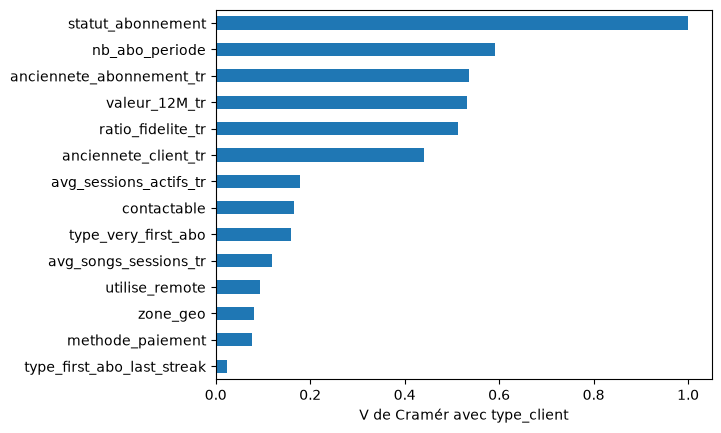

In [26]:
lien = matrice["type_client"].drop("type_client").sort_values()
print(lien.round(2))

lien.plot(kind="barh")
plt.xlabel("V de Cramér avec type_client")
plt.show()

## 8. Conclusion

Variables :
- `id_anonyme` : à enlever (identifiant)
- `statut_abonnement` : à enlever, doublon de `type_client`
- `type_first_abo_last_streak` : à enlever ou en illustrative (99 % payant)
- `type_client` et `contactable` : plutôt en illustratives

Regroupements à faire :
- `nb_abo_periode` : mettre en classes en gardant 1 et 12 à part
- `methode_paiement` : regrouper Others, Credit et Amazon
- `zone_geo` : regrouper les petites zones
- `type_very_first_abo` : regrouper offert et reduc
- anciennetés, sessions, chansons, valeur : passer à 5 ou 6 classes

Il faudra refaire le V de Cramér après les regroupements.

## 9. Modifications avant l'ACM

On applique les premières décisions sur trois variables : `nb_abo_periode`, `methode_paiement` et `zone_geo`.

On travaille sur une copie `df2`. Le tableau `df` et le fichier csv d'origine ne sont pas modifiés.

In [27]:
df2 = df.copy()
print(df2.shape)

(341092, 16)


### 9.1 nb_abo_periode

La variable est numérique, on la met en 5 classes (les mêmes que dans `regroupements.py`). On garde 1 et 12 à part parce que ce sont les deux valeurs les plus fréquentes.

In [28]:
groupes_nb_abo = {
    1: "01_1_abo",
    2: "02_2a3_abo",
    3: "02_2a3_abo",
    4: "03_4a6_abo",
    5: "03_4a6_abo",
    6: "03_4a6_abo",
    7: "04_7a11_abo",
    8: "04_7a11_abo",
    9: "04_7a11_abo",
    10: "04_7a11_abo",
    11: "04_7a11_abo",
    12: "05_12_abo",
}

df2["nb_abo_periode"] = df2["nb_abo_periode"].map(groupes_nb_abo)

In [29]:
pct = df2["nb_abo_periode"].value_counts(normalize=True).sort_index() * 100
print(pct.round(1))

nb_abo_periode
01_1_abo       28.5
02_2a3_abo     19.5
03_4a6_abo     14.4
04_7a11_abo    16.7
05_12_abo      21.0
Name: proportion, dtype: float64


Les 5 classes font entre 14 % et 29 % des clients, il n'y a plus de modalité rare.

### 9.2 methode_paiement

Trois modalités sont trop rares : Others (1 client), Credit (602) et Amazon (2 846).

In [30]:
print(df2["methode_paiement"].value_counts())

methode_paiement
Stripe     134726
Apple      111927
Android     52887
Paypal      38103
Amazon       2846
Credit        602
Others          1
Name: count, dtype: int64


#### Suppression de Others

Il n'y a qu'un seul client, on supprime la ligne.

In [31]:
df2 = df2[df2["methode_paiement"] != "Others"]
print(df2.shape)

(341091, 16)


#### Credit : avec Paypal ou avec Stripe ?

On compare le profil des clients Credit à celui des clients Paypal et Stripe avec des tableaux croisés en % en ligne.

In [32]:
autres_variables = [
    "type_client",
    "zone_geo",
    "nb_abo_periode",
    "valeur_12M_tr",
    "ratio_fidelite_tr",
    "anciennete_client_tr",
    "anciennete_abonnement_tr",
    "type_very_first_abo",
    "type_first_abo_last_streak",
    "avg_sessions_actifs_tr",
    "avg_songs_sessions_tr",
    "utilise_remote",
    "contactable",
]

In [33]:
for var in ["type_client", "nb_abo_periode", "valeur_12M_tr", "zone_geo", "utilise_remote"]:
    tableau = pd.crosstab(df2["methode_paiement"], df2[var], normalize="index") * 100
    print(tableau.loc[["Credit", "Paypal", "Stripe"]].round(1))
    print()

type_client       churn  nouveau  reactivated  retained
methode_paiement                                       
Credit             71.1      0.7         27.4       0.8
Paypal             46.2     13.5         10.8      29.5
Stripe             46.8     16.1         16.3      20.9



nb_abo_periode    01_1_abo  02_2a3_abo  03_4a6_abo  04_7a11_abo  05_12_abo
methode_paiement                                                          
Credit                 0.7        59.8        19.6         17.3        2.7
Paypal                26.0        17.3        12.0         14.3       30.4
Stripe                25.4        19.3        15.0         17.8       22.5



valeur_12M_tr     00_moins_10  01_10a15  02_15a20  03_20a25  04_25a30  \
methode_paiement                                                        
Credit                   47.7      15.3       9.0       4.0       5.3   
Paypal                   26.4       7.5       5.7       2.2       4.8   
Stripe                   26.1       5.6       8.9       1.1       6.0   

valeur_12M_tr     05_30a40  06_40a50  07_50a60  08_60a70  09_70a90  10_90a110  \
methode_paiement                                                                
Credit                 7.0       5.1       2.7       1.8       1.7        0.5   
Paypal                 5.3       4.7       4.0       5.7      17.8        3.5   
Stripe                 6.7       5.0       5.0       5.8      11.2        4.9   

valeur_12M_tr     11_110_et_plus  
methode_paiement                  
Credit                       0.0  
Paypal                      12.5  
Stripe                      13.6  

zone_geo          Afrique  Amerique_Nord_Autre  Amer

Pour résumer chaque tableau en un seul chiffre, on calcule l'écart entre deux lignes : la somme des différences de pourcentages, divisée par 2. 0 veut dire que les deux modalités ont la même répartition, 100 qu'elles n'ont rien en commun.

In [34]:
def ecart(modalite1, modalite2, var):
    tableau = pd.crosstab(df2["methode_paiement"], df2[var], normalize="index") * 100
    difference = tableau.loc[modalite1] - tableau.loc[modalite2]
    return difference.abs().sum() / 2

In [35]:
lignes = []
for var in autres_variables:
    lignes.append([var, ecart("Credit", "Paypal", var), ecart("Credit", "Stripe", var)])

ecarts_credit = pd.DataFrame(lignes, columns=["variable", "Credit_Paypal", "Credit_Stripe"])
ecarts_credit.round(1)

,variable,Credit_Paypal,Credit_Stripe
0,type_client,41.5,35.5
1,zone_geo,27.3,11.4
2,nb_abo_periode,53.1,45.1
3,valeur_12M_tr,36.8,34.6
4,ratio_fidelite_tr,32.1,30.2
5,anciennete_client_tr,26.9,22.8
6,anciennete_abonnement_tr,46.1,38.5
7,type_very_first_abo,7.6,6.3
8,type_first_abo_last_streak,95.1,95.1
9,avg_sessions_actifs_tr,16.7,14.9


In [36]:
print(ecarts_credit[["Credit_Paypal", "Credit_Stripe"]].mean().round(1))

Credit_Paypal    33.6
Credit_Stripe    29.2
dtype: float64


Credit est plus proche de Stripe que de Paypal sur 12 variables sur 13 (égalité sur la dernière), avec un écart moyen de 29,2 contre 33,6. On regroupe Credit avec Stripe.

Par contre les écarts restent grands dans les deux cas : les clients Credit ont un profil à part (71 % de churn, 95 % d'abonnements offerts). Comme ils ne sont que 602, ça ne changera presque pas le profil de Stripe.

#### Amazon : avec Android ou avec Apple ?

Même méthode.

In [37]:
for var in ["type_client", "nb_abo_periode", "valeur_12M_tr", "zone_geo", "utilise_remote"]:
    tableau = pd.crosstab(df2["methode_paiement"], df2[var], normalize="index") * 100
    print(tableau.loc[["Amazon", "Android", "Apple"]].round(1))
    print()

type_client       churn  nouveau  reactivated  retained
methode_paiement                                       
Amazon             42.1     26.8         12.8      18.4
Android            52.9     18.2         14.4      14.4
Apple              54.7     15.5         14.0      15.7

nb_abo_periode    01_1_abo  02_2a3_abo  03_4a6_abo  04_7a11_abo  05_12_abo
methode_paiement                                                          
Amazon                20.8        19.7        16.8         23.5       19.2
Android               30.8        20.6        14.6         17.1       16.9
Apple                 32.2        19.6        14.3         15.8       18.1

valeur_12M_tr     00_moins_10  01_10a15  02_15a20  03_20a25  04_25a30  \
methode_paiement                                                        
Amazon                   20.8      11.3       7.7       0.5       5.4   
Android                  30.9      12.6       0.2       7.7       5.5   
Apple                    31.3      12.2       7.6  

In [38]:
lignes = []
for var in autres_variables:
    lignes.append([var, ecart("Amazon", "Android", var), ecart("Amazon", "Apple", var)])

ecarts_amazon = pd.DataFrame(lignes, columns=["variable", "Amazon_Android", "Amazon_Apple"])
ecarts_amazon.round(1)

,variable,Amazon_Android,Amazon_Apple
0,type_client,12.6,13.9
1,zone_geo,28.8,13.8
2,nb_abo_periode,10.9,11.4
3,valeur_12M_tr,20.8,16.7
4,ratio_fidelite_tr,9.7,13.2
5,anciennete_client_tr,11.6,12.8
6,anciennete_abonnement_tr,14.3,13.6
7,type_very_first_abo,0.9,1.0
8,type_first_abo_last_streak,0.0,0.2
9,avg_sessions_actifs_tr,22.9,25.0


In [39]:
print(ecarts_amazon[["Amazon_Android", "Amazon_Apple"]].mean().round(1))

Amazon_Android    12.2
Amazon_Apple      12.1
dtype: float64


Ici c'est beaucoup plus serré : l'écart moyen est le même (12,2 avec Android, 12,1 avec Apple).

Amazon est plus proche d'Android sur 10 variables sur 13, mais à chaque fois de peu. Apple est plus proche sur 3 variables, surtout `zone_geo` (les clients Amazon sont surtout aux US et au UK, comme ceux d'Apple).

On regroupe Amazon avec Android : c'est le plus proche sur la majorité des variables, et l'Appstore Amazon fonctionne sur des appareils Android.

#### Regroupement

In [40]:
df2["methode_paiement"] = df2["methode_paiement"].replace({"Credit": "Stripe", "Amazon": "Android"})

pct = df2["methode_paiement"].value_counts(normalize=True) * 100
print(df2["methode_paiement"].value_counts())
print(pct.round(1))

methode_paiement
Stripe     135328
Apple      111927
Android     55733
Paypal      38103
Name: count, dtype: int64
methode_paiement
Stripe     39.7
Apple      32.8
Android    16.3
Paypal     11.2
Name: proportion, dtype: float64


### 9.3 zone_geo

On supprime la modalité Autre/Inconnu (22 clients), puis on regroupe les petites zones dans une seule modalité.

In [41]:
df2 = df2[df2["zone_geo"] != "Autre/Inconnu"]
print(df2.shape)

(341069, 16)


In [42]:
groupes_zone = {
    "Afrique": "Reste_du_monde",
    "Asie": "Reste_du_monde",
    "Amerique_Sud": "Reste_du_monde",
    "Amerique_Nord_Autre": "Reste_du_monde",
    "Oceanie": "Reste_du_monde",
}

df2["zone_geo"] = df2["zone_geo"].replace(groupes_zone)

pct = df2["zone_geo"].value_counts(normalize=True) * 100
print(df2["zone_geo"].value_counts())
print(pct.round(1))

zone_geo
US                140841
Europe             71144
FR                 59810
UK                 25026
CA                 23999
Reste_du_monde     20249
Name: count, dtype: int64
zone_geo
US                41.3
Europe            20.9
FR                17.5
UK                 7.3
CA                 7.0
Reste_du_monde     5.9
Name: proportion, dtype: float64


Reste_du_monde fait 5,9 % des clients, toutes les modalités sont maintenant au-dessus de 5 %.

### 9.4 Vérifications

In [43]:
print("lignes avant :", len(df))
print("lignes après :", len(df2))
print("lignes supprimées :", len(df) - len(df2))
print("valeurs manquantes :", df2.isna().sum().sum())

lignes avant : 341092
lignes après : 341069
lignes supprimées : 23
valeurs manquantes : 0


In [44]:
# le tableau d'origine n'a pas changé
print(df["methode_paiement"].nunique(), "modalités pour methode_paiement dans df")
print(df["zone_geo"].nunique(), "modalités pour zone_geo dans df")

7 modalités pour methode_paiement dans df
11 modalités pour zone_geo dans df


### 9.5 Enregistrement

On enregistre `df2` dans un nouveau fichier Excel. L'écriture prend une à deux minutes à cause du nombre de lignes.

In [45]:
df2.to_excel("td_clustering_karafun_modifie.xlsx", index=False)

### Suite

Il reste à regrouper les anciennetés, les sessions, les chansons, la valeur et `type_very_first_abo`, puis à refaire le V de Cramér sur le fichier modifié.